In [24]:
# Resnet Model for Audio Classification
# I am using features_3_sec.csv for ResNet, the dataset is pre-extracted audio features
# for this implementation, I am using these features as input to a ResNet style model approach
# ResNet is used for images, so we are modifiying it to work with tabular data
# The input is treated as feature vectors instead of 2D images
# The goal is to see how a deep residual network performs on tabular audio features

# then we will be running the real ResNet model on the spectrogram images to compare the results
# I think this is going to interesting to see how the two approaches perform on the same dataset,
# one using pre-extracted features and the other using raw spectrogram images

# so we are not comparing a ResNet on extracted features vs a ResNet on spectrogram images 
# we are comaring a ResNet style approach, residual learning on extracted features vs a real ResNet modelon spectrogram images
# the ResNet style approach on extracted features is more of an experiment 
# the ResNet on spectrogram images is the traditional approach
# 





In [25]:
import os, torch, torchaudio
from torch import device, nn, optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
from torch.utils.tensorboard.writer import SummaryWriter
from typing import cast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F

In [26]:
pip install torch torchaudio torchvision

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [28]:
# load the dataset and preprocess it to get spectrograms
data = pd.read_csv("features_3_sec.csv")

# dropping colmns we dont need
data = data.drop(columns=["filename", "length"])

# encode the labels
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["label"]) 

# split the dataset into features and labels
X = data.drop(columns=["label"]).values
y = data["label"].values

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)


# convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)   

In [29]:
# define dataset class
class MusicGenreDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
    
# define the ResNet model
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU()
        )

        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        return self.classifier(x)


In [30]:
# determine the number of classes dynamically
num_classes = len(label_encoder.classes_)

# instantiate the model
model = TabularResNet(input_dim=X_train.shape[1], num_classes=num_classes)

# define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
  
 

# disabling test for data preprocessing, as we are focusing on training the model with the ResNet architecture
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_loss += loss.item()
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_acc:.4f}")

# evaluate the model with testing dataset
model.eval()
total_correct: int = 0
total_samples: int = 0
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)

        # Forward Pass
        test_pred_labels = model(features)

        # Accuracy Compilation
        _, predicted = torch.max(test_pred_labels.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
test_accuracy = total_correct / total_samples
print(f'Test Accuracy: {test_accuracy:.4f}')    

# classification report and confusion matrix
all_labels = []
all_predictions = []
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        test_pred_labels = model(features)
        _, predicted = torch.max(test_pred_labels.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))    






Epoch 1/20, Loss: 1.0670, Accuracy: 0.6246
Epoch 2/20, Loss: 0.6445, Accuracy: 0.7775
Epoch 3/20, Loss: 0.4877, Accuracy: 0.8341
Epoch 4/20, Loss: 0.3960, Accuracy: 0.8679
Epoch 5/20, Loss: 0.3408, Accuracy: 0.8820
Epoch 6/20, Loss: 0.2762, Accuracy: 0.9055
Epoch 7/20, Loss: 0.2527, Accuracy: 0.9137
Epoch 8/20, Loss: 0.2047, Accuracy: 0.9296
Epoch 9/20, Loss: 0.1975, Accuracy: 0.9317
Epoch 10/20, Loss: 0.1584, Accuracy: 0.9476
Epoch 11/20, Loss: 0.1443, Accuracy: 0.9523
Epoch 12/20, Loss: 0.1468, Accuracy: 0.9469
Epoch 13/20, Loss: 0.1441, Accuracy: 0.9503
Epoch 14/20, Loss: 0.1124, Accuracy: 0.9605
Epoch 15/20, Loss: 0.1278, Accuracy: 0.9572
Epoch 16/20, Loss: 0.1025, Accuracy: 0.9663
Epoch 17/20, Loss: 0.1075, Accuracy: 0.9615
Epoch 18/20, Loss: 0.0926, Accuracy: 0.9706
Epoch 19/20, Loss: 0.0960, Accuracy: 0.9686
Epoch 20/20, Loss: 0.0783, Accuracy: 0.9732
Test Accuracy: 0.8934
Classification Report:
              precision    recall  f1-score   support

       blues       0.89      

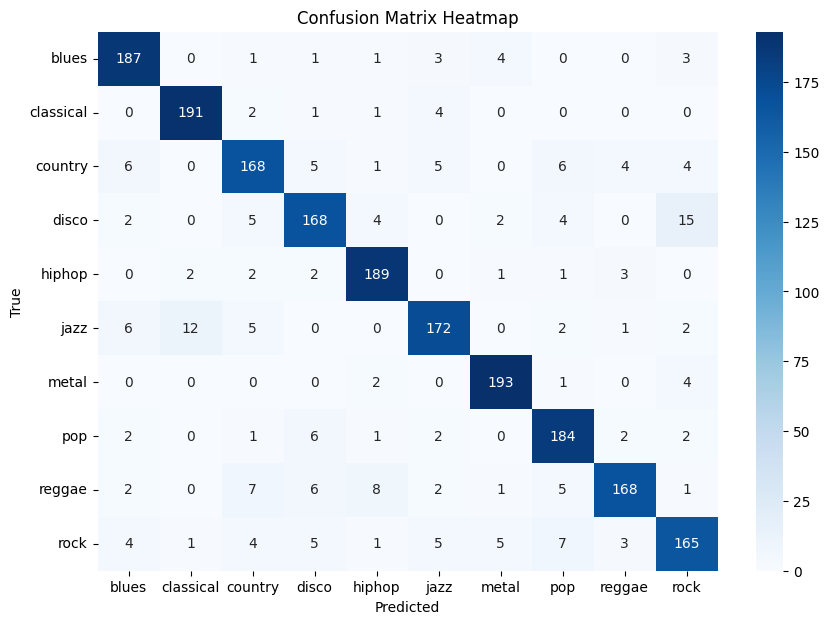

In [31]:
# confusion_matrix heat map
import seaborn as sns
import matplotlib.pyplot as plt 
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()  

In [32]:
#tensorboard
writer = SummaryWriter()
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_loss += loss.item()
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    writer.add_scalar('Loss/train', total_loss/len(train_loader), epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_acc:.4f}")
writer.close()

Epoch 1/20, Loss: 0.0888, Accuracy: 0.9696
Epoch 2/20, Loss: 0.0809, Accuracy: 0.9723
Epoch 3/20, Loss: 0.0732, Accuracy: 0.9761
Epoch 4/20, Loss: 0.0691, Accuracy: 0.9755
Epoch 5/20, Loss: 0.0809, Accuracy: 0.9713
Epoch 6/20, Loss: 0.0783, Accuracy: 0.9731
Epoch 7/20, Loss: 0.0516, Accuracy: 0.9837
Epoch 8/20, Loss: 0.0632, Accuracy: 0.9766
Epoch 9/20, Loss: 0.0656, Accuracy: 0.9782
Epoch 10/20, Loss: 0.0576, Accuracy: 0.9799
Epoch 11/20, Loss: 0.0649, Accuracy: 0.9779
Epoch 12/20, Loss: 0.0674, Accuracy: 0.9766
Epoch 13/20, Loss: 0.0548, Accuracy: 0.9825
Epoch 14/20, Loss: 0.0379, Accuracy: 0.9882
Epoch 15/20, Loss: 0.0591, Accuracy: 0.9792
Epoch 16/20, Loss: 0.0572, Accuracy: 0.9810
Epoch 17/20, Loss: 0.0484, Accuracy: 0.9835
Epoch 18/20, Loss: 0.0476, Accuracy: 0.9839
Epoch 19/20, Loss: 0.0536, Accuracy: 0.9806
Epoch 20/20, Loss: 0.0487, Accuracy: 0.9845


In [33]:
# Traditional ResNet on spectrogram images(image orginals dataset)
# this is for 30 sec images 

# Path to image folders
import torchvision


data = "images_original"

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load images from folders
dataset = datasets.ImageFolder(root=data, transform=transform)

print(dataset.classes)   # genre names
print(len(dataset))      # total images

# create data loaders
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# load pre-trained ResNet model
resnet_model = torchvision.models.resnet18(pretrained=True)
# modify the final layer for our number of classes
num_classes = len(dataset.classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model.to(device)
# define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

# how many items in each folder 
for genre in dataset.classes:
    genre_path = os.path.join(data, genre)
    num_images = len(os.listdir(genre_path))
    print(f"{genre}: {num_images} images")

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
1000
blues: 101 images
classical: 100 images
country: 100 images
disco: 100 images
hiphop: 100 images
jazz: 99 images
metal: 100 images
pop: 100 images
reggae: 100 images
rock: 100 images


/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [34]:
# train the ResNet model 
num_epochs = 15

for epoch in range(num_epochs):
    resnet_model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_loss += loss.item()
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_acc:.4f}")




Epoch 1/15, Loss: 1.5208, Accuracy: 0.5000
Epoch 2/15, Loss: 1.0575, Accuracy: 0.6587
Epoch 3/15, Loss: 0.8657, Accuracy: 0.7063
Epoch 4/15, Loss: 0.7009, Accuracy: 0.7650
Epoch 5/15, Loss: 0.4250, Accuracy: 0.8662
Epoch 6/15, Loss: 0.4124, Accuracy: 0.8575
Epoch 7/15, Loss: 0.3030, Accuracy: 0.8900
Epoch 8/15, Loss: 0.2767, Accuracy: 0.9038
Epoch 9/15, Loss: 0.1841, Accuracy: 0.9475
Epoch 10/15, Loss: 0.1906, Accuracy: 0.9413
Epoch 11/15, Loss: 0.2054, Accuracy: 0.9350
Epoch 12/15, Loss: 0.1590, Accuracy: 0.9513
Epoch 13/15, Loss: 0.1153, Accuracy: 0.9575
Epoch 14/15, Loss: 0.1217, Accuracy: 0.9613
Epoch 15/15, Loss: 0.0477, Accuracy: 0.9888


In [35]:
# evaluate the model 
resnet_model.eval()
total_correct = 0
total_samples = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
test_accuracy = total_correct / total_samples
print(f'Test Accuracy: {test_accuracy:.4f}')

# classification report and confusion matrix for ResNet model
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=dataset.classes))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))    

Test Accuracy: 0.7250
Classification Report:
              precision    recall  f1-score   support

       blues       0.83      0.56      0.67        18
   classical       0.89      0.96      0.92        25
     country       0.76      0.59      0.67        22
       disco       0.63      0.71      0.67        17
      hiphop       0.65      0.79      0.71        19
        jazz       0.90      0.90      0.90        21
       metal       0.75      0.95      0.84        19
         pop       0.90      0.41      0.56        22
      reggae       0.80      0.70      0.74        23
        rock       0.33      0.64      0.44        14

    accuracy                           0.72       200
   macro avg       0.75      0.72      0.71       200
weighted avg       0.77      0.72      0.73       200

Confusion Matrix:
[[10  0  1  0  0  1  0  0  1  5]
 [ 0 24  0  0  0  0  1  0  0  0]
 [ 0  1 13  2  0  0  0  0  0  6]
 [ 0  1  0 12  1  0  2  0  0  1]
 [ 0  0  0  0 15  0  1  0  3  0]
 [ 0  1  0  0

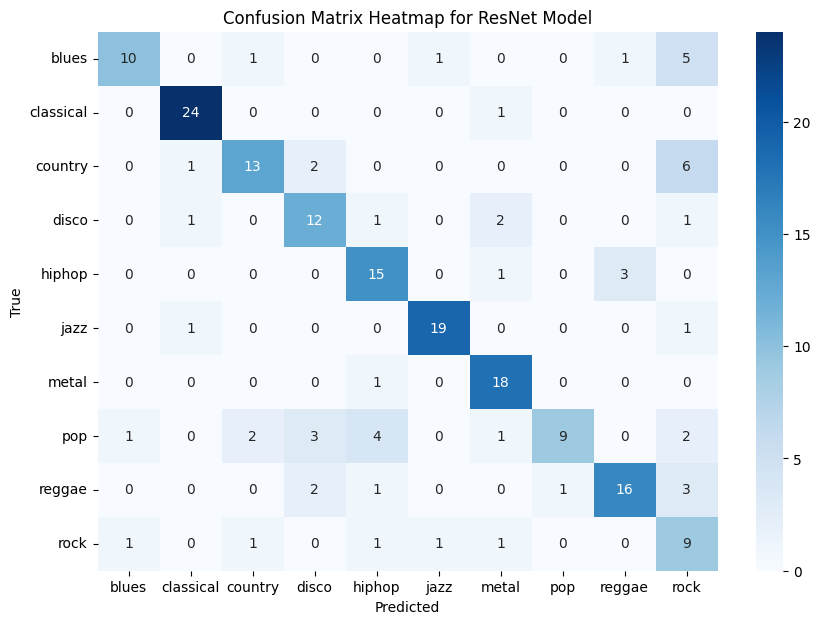

In [36]:
# confusion_matrix heat map
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap for ResNet Model')
plt.show()

In [37]:
# checking for overfitting by plotting training and validation accuracy over epochs
# plotting training and validation accuracy over epochs to check for overfitting
train_accuracies = []
val_accuracies = []
for epoch in range(num_epochs):
    resnet_model.train()
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    train_accuracies.append(train_acc)

    # Validation accuracy
    resnet_model.eval()
    val_correct = 0
    val_samples = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            val_samples += labels.size(0)

    val_acc = val_correct / val_samples
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")



Epoch 1/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7800
Epoch 2/15, Train Accuracy: 0.9938, Validation Accuracy: 0.7600
Epoch 3/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7650
Epoch 4/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7800
Epoch 5/15, Train Accuracy: 0.9962, Validation Accuracy: 0.7700
Epoch 6/15, Train Accuracy: 0.9938, Validation Accuracy: 0.7650
Epoch 7/15, Train Accuracy: 0.9875, Validation Accuracy: 0.7700
Epoch 8/15, Train Accuracy: 0.9888, Validation Accuracy: 0.7700
Epoch 9/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7700
Epoch 10/15, Train Accuracy: 0.9938, Validation Accuracy: 0.7800
Epoch 11/15, Train Accuracy: 0.9962, Validation Accuracy: 0.7900
Epoch 12/15, Train Accuracy: 0.9925, Validation Accuracy: 0.7700
Epoch 13/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7750
Epoch 14/15, Train Accuracy: 0.9912, Validation Accuracy: 0.7650
Epoch 15/15, Train Accuracy: 0.9925, Validation Accuracy: 0.7700


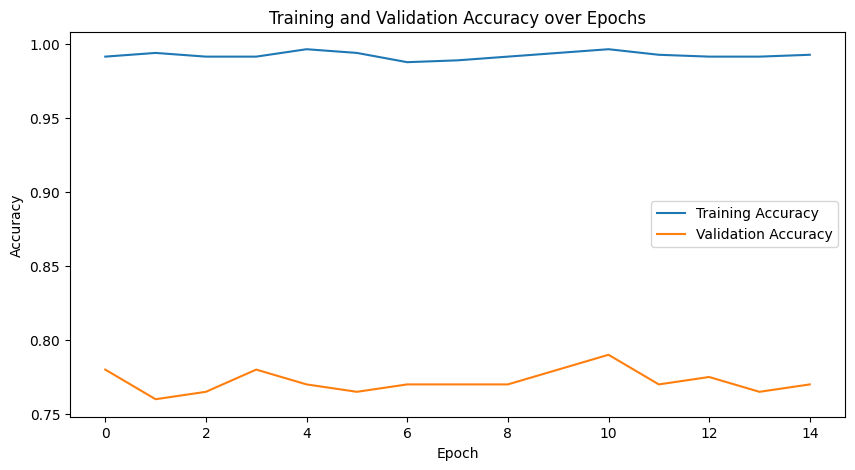

In [38]:
# plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()  

In [39]:
# Epoch = 10, accuraccy at 54% 
# Epoch = 15, accuraccy at 72%
# Epoch = 20, accuraccy at 69%
# Epoch = 25, accuraccy at 74.53%



In [40]:
pip install librosa matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [41]:
import os
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np


# split the audio into 3 sec segments and save as audio files
# uncomment to run if you dont have the files 
# -----------------------------------------------------------------------------------------------------------------------------------------------




# audio_data = "genres_original"
# output_dir = "3sec_audio"

# for genre in os.listdir(audio_data):
#     genre_path = os.path.join(audio_data, genre)
#     if not os.path.isdir(genre_path):  # skip non-directories like DS_Store
#         continue
#     output_genre_dir = os.path.join(output_dir, genre)
#     os.makedirs(output_genre_dir, exist_ok=True)
#     for audio_file in os.listdir(genre_path):
#         if not audio_file.endswith(".wav"):  # only process .wav files
#             continue
#         audio_path = os.path.join(genre_path, audio_file)
#         try:  # if audio is missing or cannot be read, skip it
#             y, sr = librosa.load(audio_path, duration=30)  # load up to 30 seconds
#         except Exception as e:
#             continue
#         # Split into 3-second segments
#         for i in range(0, len(y), sr * 3):
#             segment = y[i:i + sr * 3]
#             if len(segment) < sr * 3:
#                 break  # if segment is less than 3 seconds, skip it
#             # Save the segment as a new .wav file
#             segment_filename = f"{genre}_{audio_file}_segment_{i//(sr*3)}.wav"
#             segment_path = os.path.join(output_genre_dir, segment_filename)
#             sf.write(segment_path, segment, sr)






# split the audio into 3 sec segments then generate images for it 
# uncomment to run if you dont have the files 
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------







# audio_data = "genres_original"
# output_dir = "3sec_images"

# for genre in os.listdir(audio_data):
#     genre_path = os.path.join(audio_data, genre)
#     if not os.path.isdir(genre_path):   #I dont know wthat is DS_store, I kept getting an error, so i skipped it 
#             continue
#     output_genre_dir = os.path.join(output_dir, genre)
#     os.makedirs(output_genre_dir, exist_ok=True)
#     for audio_file in os.listdir(genre_path):
#         if not audio_file.endswith(".wav"):  # in case if there is no audio file
#             continue
#         audio_path = os.path.join(genre_path, audio_file)
#         try: # if audio is missing or can not be read, skipt it 
#             y, sr = librosa.load(audio_path, duration=30) # 
#         except Exception as e:
#             continue
#         # Split into 3 secs segments
#         for i in range(0, len(y), sr * 3):
#             segment = y[i:i + sr * 3]
#             if len(segment) < sr * 3:
#                 break  # if segment is less than 3 secs, skip it 
#             # Generate spectrogram        
#             S = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128)
#             S_dB = librosa.power_to_db(S, ref=np.max)
#             # Save spectrogram as image
#             plt.figure(figsize=(10, 4))
#             librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
#             plt.colorbar(format='%+2.0f dB')
#             plt.title(f'{genre} - {audio_file} - Segment {i//(sr*3)}')
#             plt.tight_layout()
#             plt.savefig(f'{output_genre_dir}/{genre}_{audio_file}_segment_{i//(sr*3)}.png')
#             plt.close()

# 

In [42]:
# now we have 3 sec images, we can run the ResNet model on these images 
data = "3sec_images"
# image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# load images from folders
dataset = datasets.ImageFolder(root=data, transform=transform)
print(dataset.classes)   # genre names
print(len(dataset))      # total images 




# group images by original song
song_to_indices = defaultdict(list)

for idx, (path, label) in enumerate(dataset.samples):
    filename = os.path.basename(path)

    # example: blues.00001.wav_segment_0.png → blues.00001.wav
    song_id = "_".join(filename.split("_")[:-2])

    song_to_indices[song_id].append(idx)

song_ids = list(song_to_indices.keys())

train_songs, test_songs = train_test_split(
    song_ids,
    test_size=0.2,
    random_state=42
)


train_indices = []
test_indices = []

for song in train_songs:
    train_indices.extend(song_to_indices[song])

for song in test_songs:
    test_indices.extend(song_to_indices[song])

train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))





#------------------------------------------------------------------------------------


# #create data loaders
# train_size = int(0.8 * len(dataset))
# test_size = len(dataset) - train_size
# train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# # load pre-trained ResNet model
# resnet_model = torchvision.models.resnet18(pretrained=True)

# # modify the final layer for our number of classes
# num_classes = len(dataset.classes)
# resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
# resnet_model.to(device)

# # define loss and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)



['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
9981
Train size: 7983
Test size: 1998


In [46]:
# load pre-trained ResNet model
resnet_model = torchvision.models.resnet18(pretrained=True)

# modify the final layer for our number of classes
num_classes = len(dataset.classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model.to(device)

# define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [50]:
resnet_3sec = torchvision.models.resnet18(pretrained=True)
resnet_3sec.fc = nn.Linear(resnet_3sec.fc.in_features, num_classes)
resnet_3sec.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [51]:
# train the ResNet model
num_epochs = 15
for epoch in range(num_epochs):
    resnet_model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total_loss += loss.item()
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {train_acc:.4f}")

Epoch 1/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 2/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 3/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 4/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 5/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 6/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 7/15, Loss: 0.0000, Accuracy: 1.0000
Epoch 8/15, Loss: 0.2431, Accuracy: 0.9162
Epoch 9/15, Loss: 0.0264, Accuracy: 0.9926
Epoch 10/15, Loss: 0.0091, Accuracy: 0.9972
Epoch 11/15, Loss: 0.0097, Accuracy: 0.9974
Epoch 12/15, Loss: 0.0023, Accuracy: 0.9997
Epoch 13/15, Loss: 0.0003, Accuracy: 1.0000
Epoch 14/15, Loss: 0.0067, Accuracy: 0.9982
Epoch 15/15, Loss: 0.0002, Accuracy: 1.0000


In [52]:
# evaluate the model on 3 sec images
resnet_model.eval()
total_correct = 0
total_samples = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward Pass
        test_pred_labels = resnet_model(images)

        # Accuracy Compilation
        _, predicted = torch.max(test_pred_labels.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
test_accuracy = total_correct / total_samples
print(f'Test Accuracy: {test_accuracy:.4f}')

# classification report and confusion matrix for ResNet model on 3 sec images
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=dataset.classes))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))    

Test Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

       blues       1.00      1.00      1.00       210
   classical       1.00      1.00      1.00       120
     country       1.00      1.00      1.00       240
       disco       1.00      1.00      1.00       220
      hiphop       1.00      1.00      1.00       149
        jazz       1.00      1.00      1.00       270
       metal       1.00      1.00      1.00       180
         pop       1.00      1.00      1.00       190
      reggae       1.00      1.00      1.00       220
        rock       1.00      1.00      1.00       199

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998

Confusion Matrix:
[[210   0   0   0   0   0   0   0   0   0]
 [  0 120   0   0   0   0   0   0   0   0]
 [  0   0 240   0   0   0   0   0   0   0]
 [  0   0   0 220   0   0   0   0   0   0]
 [  0 

In [53]:
# plotting training and validation accuracy for ResNet model on 3 sec images
train_accuracies = []
val_accuracies = []
for epoch in range(num_epochs):
    resnet_model.train()
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    train_accuracies.append(train_acc)

    # validation accuracy
    resnet_model.eval()
    val_correct = 0
    val_samples = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            val_samples += labels.size(0)

    val_acc = val_correct / val_samples
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

Epoch 1/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 2/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 3/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 4/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 5/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 6/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 7/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 8/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 9/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 10/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 11/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 12/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 13/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 14/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
Epoch 15/15, Train Accuracy: 1.0000, Validation Accuracy: 1.0000
